In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image


BASE_DIR = "/content/drive/MyDrive/EMBED"
SPLIT_DIR = os.path.join(BASE_DIR, "splits")

TRAIN_CSV = os.path.join(SPLIT_DIR, "train_512.csv")
VAL_CSV = os.path.join(SPLIT_DIR, "val_512.csv")
TEST_CSV = os.path.join(SPLIT_DIR, "test_512.csv")

MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

In [38]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("Train patients:", train_df["empi_anon"].nunique())
print("Val patients:", val_df["empi_anon"].nunique())
print("Test patients:", test_df["empi_anon"].nunique())

Train: (697, 13)
Val: (168, 13)
Test: (173, 13)
Train patients: 28
Val patients: 6
Test patients: 6


In [39]:
risk_cols = ["risk_1yr", "risk_2yr", "risk_3yr", "risk_4yr", "risk_5yr"]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [40]:
class EMBEDFutureRiskDataset(Dataset):
    def __init__(self, dataframe, risk_cols, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.risk_cols = risk_cols
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["processed_image_path"]
        image = Image.open(image_path).convert("L")

        labels = row[self.risk_cols].values.astype("float32")
        labels = torch.tensor(labels, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, labels

In [41]:
BATCH_SIZE = 4

train_dataset = EMBEDFutureRiskDataset(train_df, risk_cols, train_transform)
val_dataset = EMBEDFutureRiskDataset(val_df, risk_cols, val_test_transform)
test_dataset = EMBEDFutureRiskDataset(test_df, risk_cols, val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print(labels)

Image batch shape: torch.Size([4, 3, 512, 512])
Label batch shape: torch.Size([4, 5])
tensor([[0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 1.],
        [0., 1., 1., 1., 1.]])


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
model = models.resnet50(weights="DEFAULT")

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 5)
)

model = model.to(device)

print(model.fc)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-5
)

Device: cuda
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=5, bias=True)
)


In [43]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        progress_bar.set_postfix({
            "Batch Loss": f"{loss.item():.4f}"
        })

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

In [44]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            progress_bar.set_postfix({
                "Batch Loss": f"{loss.item():.4f}"
            })

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

In [49]:
NUM_EPOCHS = 10

best_val_loss = float("inf")

train_losses = []
val_losses = []

best_model_path = os.path.join(
    MODEL_DIR,
    "best_resnet50_embed_5yr_risk.pth"
)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

    print("-" * 50)


Epoch [1/10]


Train Loss: 0.6113
Val Loss:   0.6285
Best model saved.
--------------------------------------------------

Epoch [2/10]


Train Loss: 0.6058
Val Loss:   0.6248
Best model saved.
--------------------------------------------------

Epoch [3/10]


Train Loss: 0.6000
Val Loss:   0.6185
Best model saved.
--------------------------------------------------

Epoch [4/10]


Train Loss: 0.5978
Val Loss:   0.6159
Best model saved.
--------------------------------------------------

Epoch [5/10]


...

Train Loss: 0.5934
Val Loss:   0.6109
Best model saved.
--------------------------------------------------

Epoch [7/10]


Train Loss: 0.5902
Val Loss:   0.6078
Best model saved.
--------------------------------------------------

Epoch [8/10]


Train Loss: 0.5895
Val Loss:   0.6062
Best model saved.
--------------------------------------------------

Epoch [9/10]


Train Loss: 0.5883
Val Loss:   0.6054
Best model saved.
--------------------------------------------------

Epoch [10/10]


Train Loss: 0.5886
Val Loss:   0.6061
--------------------------------------------------


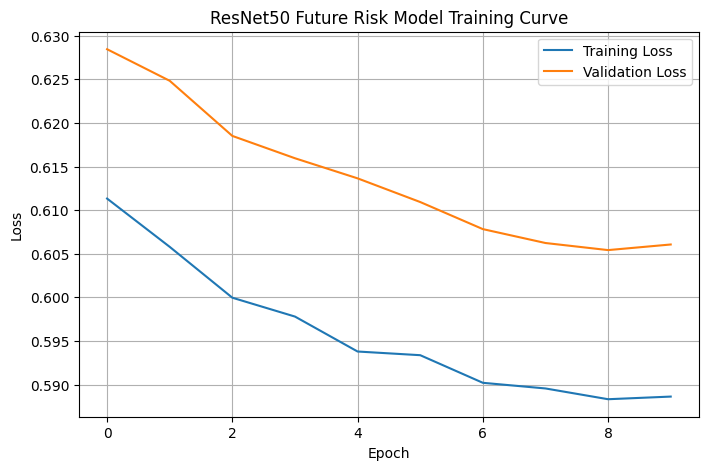

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Future Risk Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def get_predictions(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    return all_probs, all_labels

def evaluate_multilabel_model(y_true, y_probs, risk_cols, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)

    results = []

    for i, col in enumerate(risk_cols):
        results.append({
            "Risk Window": col,
            "Accuracy": accuracy_score(y_true[:, i], y_pred[:, i]),
            "Precision": precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "Recall": recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "F1": f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
            "ROC-AUC": roc_auc_score(y_true[:, i], y_probs[:, i])
        })

    return pd.DataFrame(results)

In [52]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

val_probs, val_labels = get_predictions(model, val_loader, device)

val_results = evaluate_multilabel_model(
    val_labels,
    val_probs,
    risk_cols
)

val_results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Risk Window,Accuracy,Precision,Recall,F1,ROC-AUC
0,risk_1yr,1.000000,0.000000,0.000000,0.000000,NaN
1,risk_2yr,0.613095,0.000000,0.000000,0.000000,0.589694
2,risk_3yr,0.636905,0.583333,0.215385,0.314607,0.680060
3,risk_4yr,0.386905,0.386905,1.000000,0.557940,0.481404
4,risk_5yr,0.386905,0.386905,1.000000,0.557940,0.527409


In [53]:
test_probs, test_labels = get_predictions(model, test_loader, device)

test_results = evaluate_multilabel_model(
    test_labels,
    test_probs,
    risk_cols
)

test_results

,Risk Window,Accuracy,Precision,Recall,F1,ROC-AUC
0,risk_1yr,0.947977,0.000000,0.0,0.000000,0.321816
1,risk_2yr,0.947977,0.000000,0.0,0.000000,0.260840
2,risk_3yr,0.601156,0.000000,0.0,0.000000,0.086043
3,risk_4yr,0.052023,0.052023,1.0,0.098901,0.536585
4,risk_5yr,0.514451,0.514451,1.0,0.679389,0.685928
